In [1]:
import pandas as pd
import numpy as np



In [5]:
plasma_data = pd.read_csv('plasma_data_imputed_30_renamed.csv')
tissue_data = pd.read_csv('tissue_data_imputed_30_renamed.csv')
gene_edges_model = pd.read_csv('gene_edges_model.csv')

print(plasma_data.shape)
print(tissue_data.shape)

(1531, 53)
(6630, 53)


In [14]:
graph_genes = set(
    gene_edges_model["gene1"]
).union(
    set(gene_edges_model["gene2"])
)

In [18]:
plasma_proteins = set(protein for protein in plasma_data['Genes'].values if protein in graph_genes)
tissue_proteins = set(protein for protein in tissue_data['Genes'].values if protein in graph_genes)

shared_proteins = set(protein for protein in tissue_proteins if protein in plasma_proteins)
plasma_only_proteins = plasma_proteins.difference(shared_proteins)
tissue_only_proteins = tissue_proteins.difference(shared_proteins)

print(f'Shared proteins: {len(shared_proteins)}')
print(f'Plasma only proteins: {len(plasma_only_proteins)}')
print(f'Tissue only proteins: {len(tissue_only_proteins)}')

Shared proteins: 1316
Plasma only proteins: 98
Tissue only proteins: 5145


In [8]:
connectivity_400 = gene_edges_model[
    gene_edges_model["combined_score"] >= 400
]
graph_genes_400 = set(
    connectivity_400["gene1"]
).union(
    set(connectivity_400["gene2"])
)
connectivity_700 = gene_edges_model[
    gene_edges_model["combined_score"] >= 700
]
graph_genes_700 = set(
    connectivity_700["gene1"]
).union(
    set(connectivity_700["gene2"])
)

print('connectivity values stats:')
print(gene_edges_model["combined_score"].describe())
print('edges above value of 400:',len(connectivity_400))
print('nodes with only edges above 400:',len(graph_genes_400))
print('edges above value of 700:',len(connectivity_700))
print('nodes with only edges above 700:',len(graph_genes_700))
print('mean:',gene_edges_model["combined_score"].mean())
print('median:',gene_edges_model["combined_score"].median())
print('max:',gene_edges_model["combined_score"].max())
print('min:',gene_edges_model["combined_score"].min())

connectivity values stats:
count    1.790771e+06
mean     2.861111e+02
std      1.756873e+02
min      1.500000e+02
25%      1.750000e+02
50%      2.180000e+02
75%      3.200000e+02
max      9.990000e+02
Name: combined_score, dtype: float64
edges above value of 400: 293390
nodes with only edges above 400: 6549
edges above value of 700: 87402
nodes with only edges above 700: 6003
mean: 286.11109404831774
median: 218.0
max: 999
min: 150


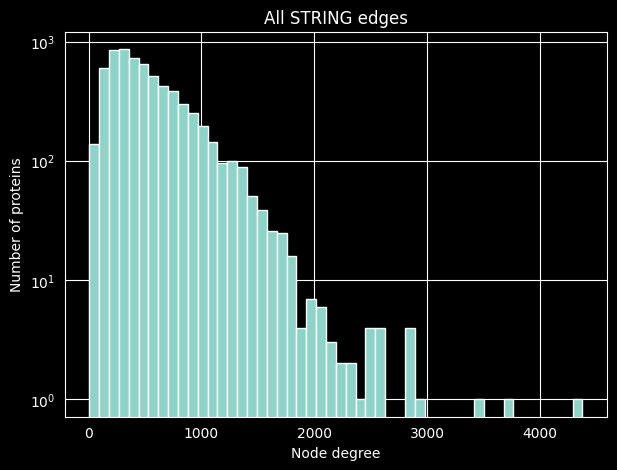

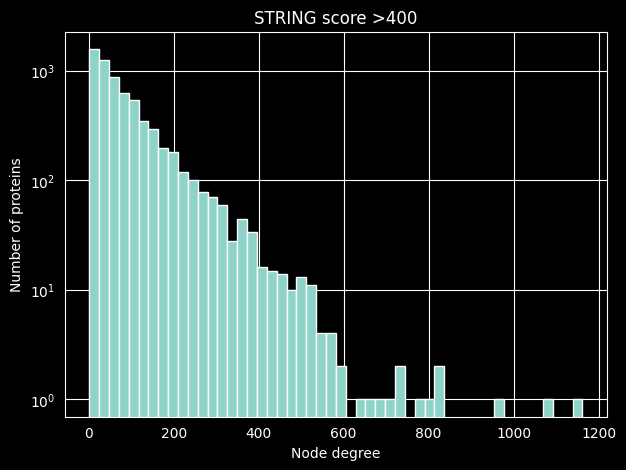

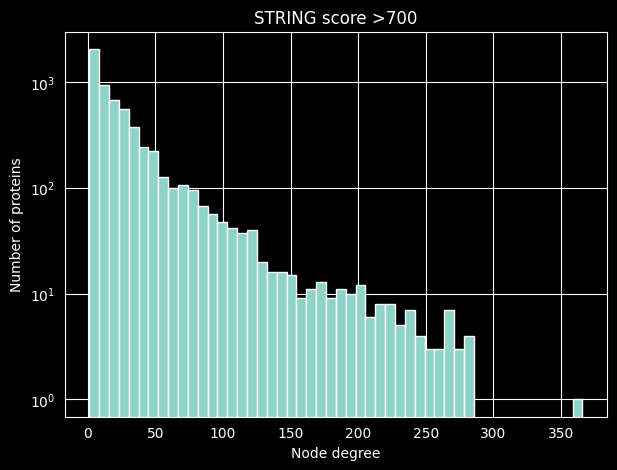

In [9]:
import matplotlib.pyplot as plt
import networkx as nx


def plot_degree_distribution(edge_df, title):

    G = nx.from_pandas_edgelist(
        edge_df,
        source="gene1",
        target="gene2",
        edge_attr="combined_score"
    )

    degrees = [d for _, d in G.degree()]

    plt.figure(figsize=(7,5))
    plt.hist(degrees, bins=50)
    plt.xlabel("Node degree")
    plt.ylabel("Number of proteins")
    plt.title(title)
    plt.yscale("log")
    plt.show()


plot_degree_distribution(
    gene_edges_model,
    "All STRING edges"
)

plot_degree_distribution(
    connectivity_400,
    "STRING score >400"
)

plot_degree_distribution(
    connectivity_700,
    "STRING score >700"
)

In [10]:
for name, edges in [
    ("all", gene_edges_model),
    ("400", connectivity_400),
    ("700", connectivity_700)
]:

    G = nx.from_pandas_edgelist(
        edges,
        source="gene1",
        target="gene2"
    )

    components = list(nx.connected_components(G))

    print(
        name,
        "components:",
        len(components),
        "largest:",
        len(max(components,key=len))
    )

all components: 1 largest: 6559
400 components: 2 largest: 6547
700 components: 12 largest: 5981


In [23]:
node_colors = {}
for p in shared_proteins:
    node_colors[p] = "#2ca02c"   # green

for p in plasma_only_proteins:
    node_colors[p] = "#d62728"   # red

for p in tissue_only_proteins:
    node_colors[p] = "#1f77b4"   # blue
# for protein in shared_proteins:
#     node_colors[protein] = "green"
#
# for protein in plasma_only_proteins:
#     node_colors[protein] = "red"
#
# for protein in tissue_only_proteins:
#     node_colors[protein] = "blue"

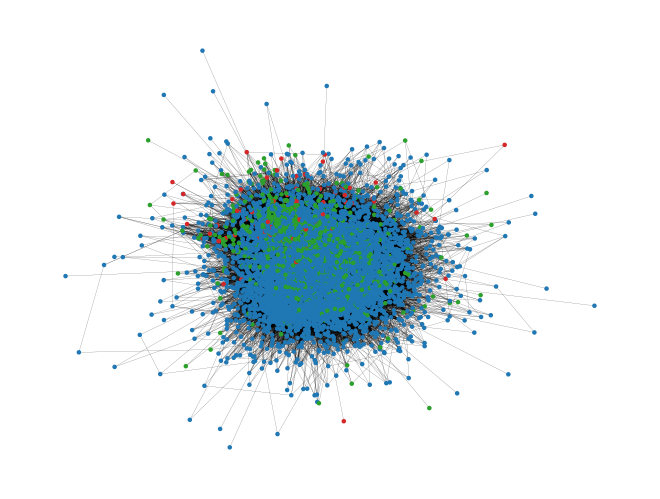

In [24]:
G = nx.from_pandas_edgelist(
    connectivity_400,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)

largest_cc = max(nx.connected_components(G), key=len)

G_sub = G.subgraph(largest_cc)
colors = [
    node_colors.get(node, "gray")
    for node in G_sub.nodes()
]

nx.draw_spring(
    G_sub,
    node_size=5,
    width=0.1,
    node_color=colors
)

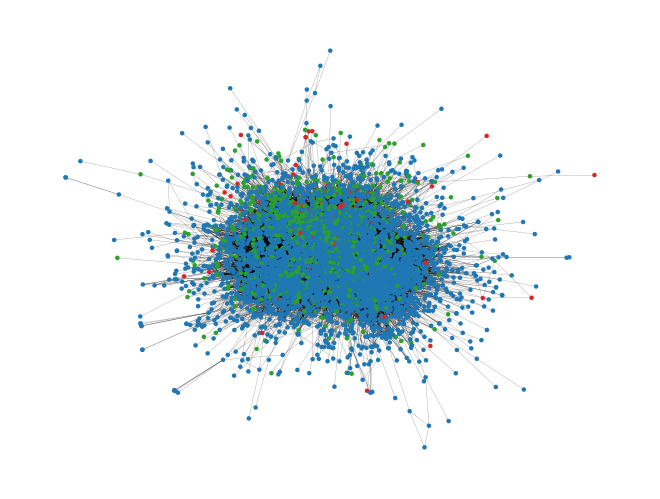

In [25]:
G = nx.from_pandas_edgelist(
    connectivity_700,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)

largest_cc = max(nx.connected_components(G), key=len)

G_sub = G.subgraph(largest_cc)
colors = [
    node_colors.get(node, "gray")
    for node in G_sub.nodes()
]
nx.draw_spring(
    G_sub,
    node_size=5,
    width=0.1,
    node_color=colors
)

In [27]:
from pyvis.network import Network
G400 = nx.from_pandas_edgelist(
    connectivity_400,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)
net = Network(
    height="900px",
    width="100%",
    bgcolor="white",
    notebook=True,
    cdn_resources="in_line"
)

for node in G400.nodes():
    net.add_node(node, label=node, color=node_colors.get(node, "gray")
)

for u,v,data in G400.edges(data=True):
    net.add_edge(
        u,
        v,
        value=data["combined_score"]
    )
net.write_html("protein_graph.html")
